In [1]:
import dpluspy
import demes 
import moments 
import msprime
import numpy as np
import pandas
import scipy

In [29]:
import matplotlib, matplotlib.pylab as plt

plt.rcParams["legend.title_fontsize"] = "small"
matplotlib.rc("xtick", labelsize=9)
matplotlib.rc("ytick", labelsize=9)
matplotlib.rc("axes", labelsize=9)
matplotlib.rc("axes", titlesize=9)
matplotlib.rc("legend", fontsize=7)
plt.rcParams['legend.title_fontsize'] = 'small'


# plot parameters
alpha = 0.5
color0 = "blue"
color1 = "orange"
color2 = "green"

In [24]:
# Merge replicate tables together
trial_tbls0 = []
for ii in range(100):
    try:
        _tbl = pandas.read_csv(f"trials/symmetry_LRT_model0_rep{ii}.csv")
        trial_tbls0.append(_tbl)
    except:
        print(f"missing trial {ii}")
tbl0 = pandas.concat(trial_tbls0)
tbl0.to_csv("model0_tbl.csv", index=False)

trial_tbls1 = []
for ii in range(100):
    try:
        _tbl = pandas.read_csv(f"trials/symmetry_LRT_model1_rep{ii}.csv")
        trial_tbls1.append(_tbl)
    except:
        print(f"missing trial {ii}")
tbl1 = pandas.concat(trial_tbls1)
tbl1.to_csv("model1_tbl.csv", index=False)

In [25]:
# extrema
print(np.min(tbl0["D_naive"]), np.max(tbl0["D_naive"]))
print(np.min(tbl0["D_adj0"]), np.max(tbl0["D_adj0"]))
print(np.min(tbl0["D_adj1"]), np.max(tbl0["D_adj1"]))

print(np.min(tbl1["D_naive"]), np.max(tbl1["D_naive"]))
print(np.min(tbl1["D_adj0"]), np.max(tbl1["D_adj0"]))
print(np.min(tbl1["D_adj1"]), np.max(tbl1["D_adj1"]))

0.0397102812344485 123.74662380929288
0.0027156315259931 2.349980418625566
0.002732467740566 9.26760955628922
367.20465277504366 2077.902446059747
2.163249330139036 7.123248644814391
24.47203571060503 151.31018834643254


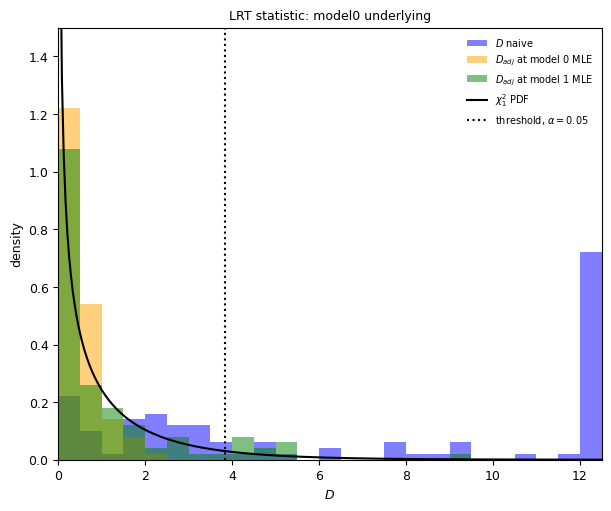

In [30]:
# Plot LRT statistics for model0
fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")

bins = np.concatenate([np.linspace(0, 12, 25), [1e4]])
counts_naive_0 = np.histogram(tbl0["D_naive"], bins)[0]
counts_adj0_0 = np.histogram(tbl0["D_adj0"], bins)[0]
counts_adj0_1 = np.histogram(tbl0["D_adj1"], bins)[0]

# bins for plotting
_bins = np.concatenate([bins[:-1], [bins[-2] + bins[-2] - bins[-3]]])
plt.hist(bins[:-1], bins=_bins, weights=counts_naive_0, color=color0, 
    density=True, alpha=alpha, label="$D$ naive",)
plt.hist(bins[:-1], bins=_bins, weights=counts_adj0_0, color=color1, 
    density=True, alpha=alpha, label="$D_{adj}$ at model 0 MLE")
plt.hist(bins[:-1], bins=_bins, weights=counts_adj0_1, color=color2,  
    density=True, alpha=alpha, label="$D_{adj}$ at model 1 MLE",)

# Plot the chi2 distribution with 1 df (the asymptotic null distribution)
df = 1
xx = np.linspace(0, _bins[-1], 300)
yy = scipy.stats.chi2.pdf(xx, df)
plt.plot(xx, yy, color="black", label=r"$\chi^2_1$ PDF")

# Plot the rejection threshold
thresh = scipy.stats.chi2.isf(0.05, 1)
ax.vlines(thresh, 0, 10, color="black", linestyles="dotted", 
    label=r"threshold, $\alpha=0.05$")

ax.set_ylim(0, 1.5)
ax.set_xlim(0, _bins[-1])
ax.set_ylabel("density")
ax.set_xlabel("$D$")
ax.legend(framealpha=0)
ax.set_title("LRT statistic: model0 underlying")
plt.savefig("figures/fig_LRT_distrs_model0.pdf")

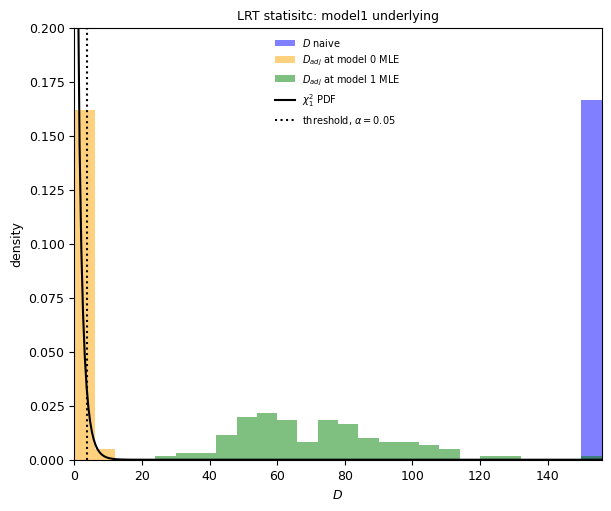

In [31]:
# Plot LRT statistics for model1
fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")

bins = np.concatenate([np.linspace(0, 150, 26), [1e4]])
counts_naive_0 = np.histogram(tbl1["D_naive"], bins)[0]
counts_adj0_0 = np.histogram(tbl1["D_adj0"], bins)[0]
counts_adj0_1 = np.histogram(tbl1["D_adj1"], bins)[0]

# bins for plotting
_bins = np.concatenate([bins[:-1], [bins[-2] + bins[-2] - bins[-3]]])
plt.hist(bins[:-1], bins=_bins, weights=counts_naive_0, color=color0, 
    density=True, alpha=alpha, label="$D$ naive",)
plt.hist(bins[:-1], bins=_bins, weights=counts_adj0_0, color=color1, 
    density=True, alpha=alpha, label="$D_{adj}$ at model 0 MLE")
plt.hist(bins[:-1], bins=_bins, weights=counts_adj0_1, color=color2,  
    density=True, alpha=alpha, label="$D_{adj}$ at model 1 MLE",)

# Plot the chi2 distribution with 1 df (the asymptotic null distribution)
df = 1
xx = np.linspace(0, _bins[-1], 300)
yy = scipy.stats.chi2.pdf(xx, df)
plt.plot(xx, yy, color="black", label=r"$\chi^2_1$ PDF")

# Plot the rejection threshold
thresh = scipy.stats.chi2.isf(0.05, 1)
ax.vlines(thresh, 0, 10, color="black", linestyles="dotted", 
    label=r"threshold, $\alpha=0.05$")

ax.set_ylim(0, 0.2)
ax.set_xlim(0, _bins[-1])
ax.set_ylabel("density")
ax.set_xlabel("$D$")
ax.legend(framealpha=0)
ax.set_title("LRT statisitc: model1 underlying")
plt.savefig("figures/fig_LRT_distrs_model1.pdf")

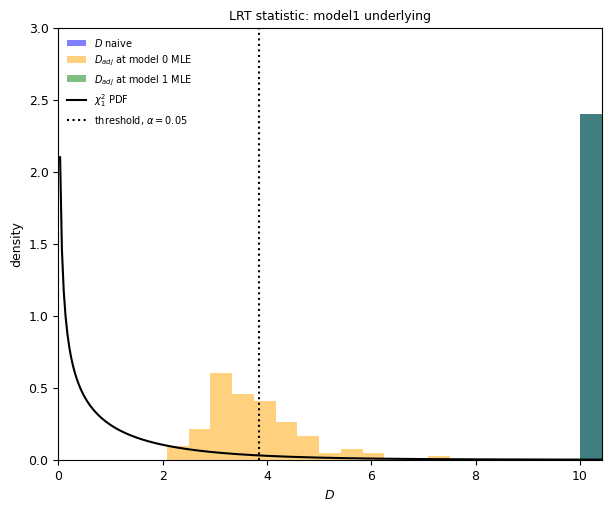

In [32]:
# Plot LRT statistics for model1
fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")

bins = np.concatenate([np.linspace(0, 10, 25), [1e4]])
counts_naive_0 = np.histogram(tbl1["D_naive"], bins)[0]
counts_adj0_0 = np.histogram(tbl1["D_adj0"], bins)[0]
counts_adj0_1 = np.histogram(tbl1["D_adj1"], bins)[0]

# bins for plotting
_bins = np.concatenate([bins[:-1], [bins[-2] + bins[-2] - bins[-3]]])
plt.hist(bins[:-1], bins=_bins, weights=counts_naive_0, color=color0, 
    density=True, alpha=alpha, label="$D$ naive",)
plt.hist(bins[:-1], bins=_bins, weights=counts_adj0_0, color=color1, 
    density=True, alpha=alpha, label="$D_{adj}$ at model 0 MLE")
plt.hist(bins[:-1], bins=_bins, weights=counts_adj0_1, color=color2,  
    density=True, alpha=alpha, label="$D_{adj}$ at model 1 MLE",)

# Plot the chi2 distribution with 1 df (the asymptotic null distribution)
df = 1
xx = np.linspace(0, _bins[-1], 300)
yy = scipy.stats.chi2.pdf(xx, df)
plt.plot(xx, yy, color="black", label=r"$\chi^2_1$ PDF")

# Plot the rejection threshold
thresh = scipy.stats.chi2.isf(0.05, 1)
ax.vlines(thresh, 0, 10, color="black", linestyles="dotted", 
    label=r"threshold, $\alpha=0.05$")

ax.set_ylim(0, 3)
ax.set_xlim(0, _bins[-1])
ax.set_ylabel("density")
ax.set_xlabel("$D$")
ax.legend(framealpha=0)
ax.set_title("LRT statistic: model1 underlying")
plt.savefig("figures/fig_LRT_distrs_model1_zoomed.pdf")

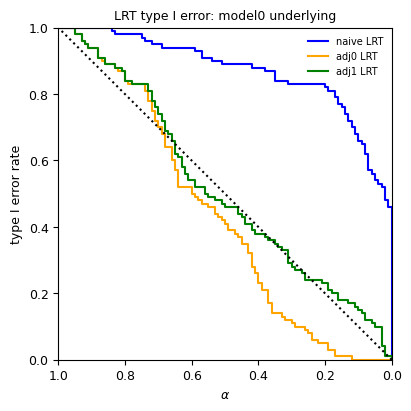

In [33]:
# Plot type I error rates (model0 results)
fig, ax = plt.subplots(figsize=(4, 4), layout="constrained")

p_naive = np.array(tbl0["p_naive"])
p_adj0 = np.array(tbl0["p_adj0"])
p_adj1 = np.array(tbl0["p_adj1"])

alphas = np.linspace(0, 1, 101)
naive_error = np.array([np.count_nonzero(p_naive < a) / len(p_naive) for a in alphas])
adj0_error = np.array([np.count_nonzero(p_adj0 < a) / len(p_adj0) for a in alphas])
adj1_error = np.array([np.count_nonzero(p_adj1 < a) / len(p_adj1) for a in alphas])
                      
plt.step(alphas, naive_error, color=color0, label="naive LRT")
plt.step(alphas, adj0_error, color=color1, label="adj0 LRT")
plt.step(alphas, adj1_error, color=color2, label="adj1 LRT")

ax.plot([0, 1], [0, 1], color="black", linestyle="dotted")
ax.set_ylim(0, 1)
ax.set_xlim(0, 1)
ax.set_ylabel("type I error rate")
ax.set_xlabel(r"$\alpha$")
ax.invert_xaxis()
ax.legend(framealpha=0)
ax.set_title("LRT type I error: model0 underlying")
plt.savefig("figures/fig_model0_typeI_error.pdf")